# Toyota Corolla Price Prediction - Multiple Linear Regression Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


data_path = '/content/ToyotaCorolla - MLR.csv'
df = pd.read_csv(data_path, encoding='latin1')


print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


## 1. Exploratory Data Analysis (EDA)

We'll check for missing values, analyze the distribution of the target variable (Price), and look for correlations.

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000



Missing values:
 Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


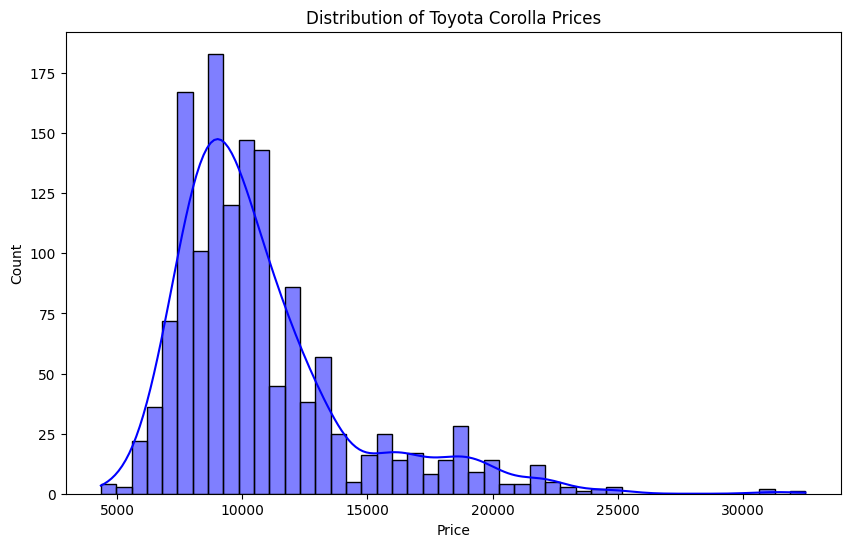

In [14]:

display(df.describe())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Visualizing the distribution of Price
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Toyota Corolla Prices')
plt.show()

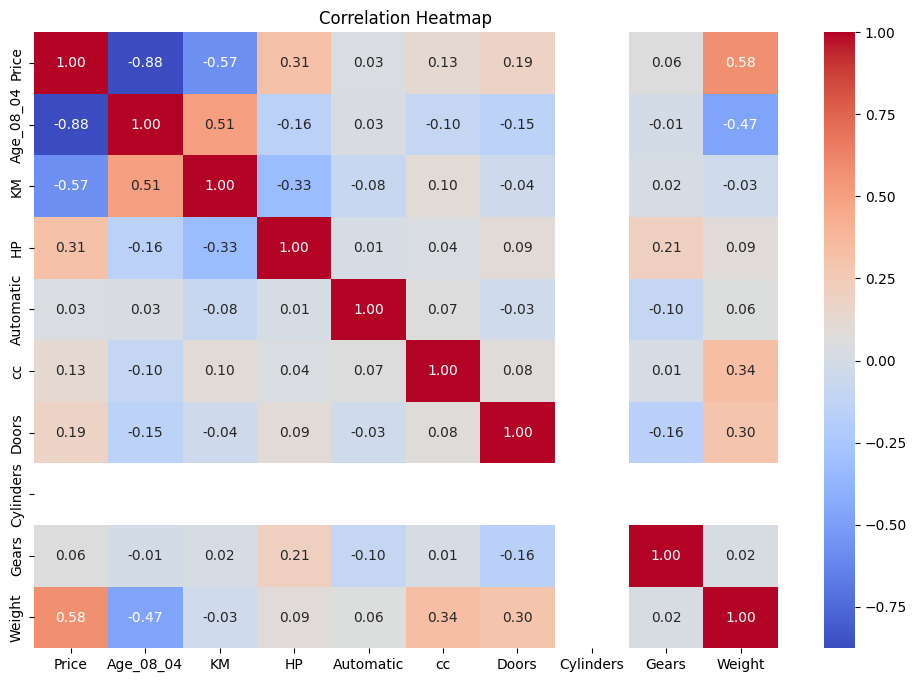

In [3]:
# Correlation Matrix for numerical variables
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 2. Data Preprocessing & Splitting

We will drop redundant columns (like 'Cylinders' which is constant), handle categorical variables using one-hot encoding, and split the data into training (80%) and testing (20%) sets.

In [15]:
# Drop 'Cylinders' as it has constant value 4
df_model = df.drop(['Cylinders'], axis=1)

# Defining features (X) and target (y)
X = df_model.drop('Price', axis=1)
y = df_model['Price']

# Preprocessing for categorical data (Fuel_Type)
X = pd.get_dummies(X, columns=['Fuel_Type'], drop_first=True)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1148, 10)
Testing set shape: (288, 10)


## 3. Build 3 Different MLR Models

We will create three variations to compare performance:
1. **Model 1**: Standard Linear Regression with all features.
2. **Model 2**: Linear Regression using only the top 3 correlated features (Age, KM, Weight).
3. **Model 3**: Linear Regression with all features and Standardization.

In [11]:
# Model 1: All features
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Model 2: Selected features (Age_08_04, KM, Weight)
features2 = ['Age_08_04', 'KM', 'Weight']
model2 = LinearRegression()
model2.fit(X_train[features2], y_train)

# Model 3: All features with Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)

print("Model 1 Coefficients:", model1.coef_)
print("Model 2 R2 Score:", model2.score(X_test[features2], y_test))

Model 1 Coefficients: [-1.20830458e+02 -1.62314106e-02  1.40394788e+01  1.48830927e+02
 -3.03721946e-02 -6.03109744e+01  5.51600710e+02  2.58849583e+01
 -6.85487568e+01  1.37080891e+03]
Model 2 R2 Score: 0.8324973071292439


## 4. Evaluation and Regularization (Lasso/Ridge)


In [12]:
# Evaluate Model 1
y_pred1 = model1.predict(X_test)
print(f"Model 1 - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1)):.2f}, R2: {r2_score(y_test, y_pred1):.4f}")

# Lasso and Ridge (applied to scaled data)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print(f"Lasso Test R2: {lasso.score(X_test_scaled, y_test):.4f}")
print(f"Ridge Test R2: {ridge.score(X_test_scaled, y_test):.4f}")

Model 1 - RMSE: 1484.27, R2: 0.8349
Lasso Test R2: 0.8351
Ridge Test R2: 0.8350


## Interview Questions

**1. What is Normalization & Standardization and how is it helpful?**
- **Normalization (Min-Max Scaling)**: Rescales the data to a range [0, 1]. It is useful when features have different ranges and the algorithm (like KNN) is sensitive to magnitudes.
- **Standardization (Z-score scaling)**: Centers the data around a mean of 0 with a standard deviation of 1. It is helpful for algorithms that assume a Gaussian distribution, such as Linear Regression and Logistic Regression, and makes the model less sensitive to outliers compared to normalization.

**2. What techniques can be used to address multicollinearity in multiple linear regression?**
- **VIF (Variance Inflation Factor)**: Identify and remove features with high VIF (usually > 5 or 10).
- **Feature Selection**: Remove one of the highly correlated features.
- **Principal Component Analysis (PCA)**: Transform correlated features into a smaller set of uncorrelated components.
- **Regularization**: Use Ridge or Lasso regression, which penalize coefficients to reduce the impact of multicollinearity.